# Embedding Cliffs

Probing what single embedding dimensions and word-difference directions do inside a running GGUF model, by injecting perturbed vectors via the raw `llama_batch` API and asking the model itself to explain what changed.

One cell per use case. Run the **Setup** cell first; everything after reuses `embd_probe.py`'s functions directly instead of re-implementing the ctypes plumbing.

Swap `MODEL_PATH` for a bigger instruct model (e.g. Llama-3.1-8B-Instruct) to reproduce the sharper results noted in a few cells below.

In [1]:
import sys
sys.path.insert(0, ".")
import embd_probe as m
from llama_cpp import Llama

MODEL_PATH = "/home/victor/text-generation-webui/user_data/models/Llama-3.2-1B-Instruct-Q8_0.gguf"

# logits_all=True works around a NULL-logits bug when driving llama_decode manually -- see embd_probe.py
llm = Llama(model_path=MODEL_PATH, n_ctx=2048, n_gpu_layers=0, logits_all=True, verbose=False)
ctx = llm.ctx
n_vocab = llm.n_vocab()
n_embd = llm.n_embd()
eos_id = llm.token_eos()
template = m.get_chat_template(llm)          # None if the GGUF has no chat_template metadata
embed_table = m.load_token_embeddings(MODEL_PATH)   # (n_vocab, n_embd) float32, dequantized straight from the GGUF

print(f"n_vocab={n_vocab} n_embd={n_embd} chat_template={'yes' if template else 'no'}")


def ask(prompt, target=None, perturb_fn=None, n_predict=50):
    """Render `prompt` through the chat template, optionally perturbing just the
    substring `target` with perturb_fn(vecs) -> vecs, and generate a continuation.
    perturb_fn=None runs the plain, unperturbed baseline."""
    token_ids = m.tokenize_prompt(llm, template, prompt)
    content_range = None
    if target is not None:
        content_ids = llm.tokenize(prompt.encode("utf-8"), add_bos=False, special=False)
        span = m.find_subsequence(token_ids, content_ids)
        target_ids = llm.tokenize(target.encode("utf-8"), add_bos=False, special=False)
        rel = m.find_subsequence(content_ids, target_ids)
        content_range = (span[0] + rel[0], span[0] + rel[1])
    m._kv_cache_clear(ctx)
    if perturb_fn is None:
        n_past = m.decode_tokens(ctx, token_ids, 0)
    else:
        n_past = m.decode_perturbed(ctx, embed_table, token_ids, n_embd, perturb_fn, content_range)
    return m.generate(llm, ctx, n_vocab, n_past, n_predict, eos_id)


def explain(full_text_a, full_text_b, n_predict=70):
    """Ask the model, unperturbed, to explain the difference between two full texts."""
    return m.explain_diff(llm, ctx, n_vocab, template, full_text_a, full_text_b, n_predict, eos_id)


n_vocab=128256 n_embd=2048 chat_template=yes


## Use case: cosine similarity sanity check

Before trusting any direction math, confirm the geometry behaves sensibly. Note the leading space on each word -- BPE tokenizes `"tiger"` and `" tiger"` as different tokens; only the space-prefixed, word-initial form is the clean single-token comparison.

In [2]:
m.print_cosine(llm, embed_table, " cat", " dog")
print()
m.print_cosine(llm, embed_table, " cat", " car")
print()
m.print_cosine(llm, embed_table, " cat", " tiger")


' cat' -> [(8415, ' cat')]
' dog' -> [(5679, ' dog')]

per-token cosine similarity:
                            ' dog'
          ' cat'            0.3402

pooled (mean-of-tokens) cosine similarity: 0.3402

' cat' -> [(8415, ' cat')]
' car' -> [(1841, ' car')]

per-token cosine similarity:
                            ' car'
          ' cat'            0.1985

pooled (mean-of-tokens) cosine similarity: 0.1985

' cat' -> [(8415, ' cat')]
' tiger' -> [(52835, ' tiger')]

per-token cosine similarity:
                          ' tiger'
          ' cat'            0.1453

pooled (mean-of-tokens) cosine similarity: 0.1453


## Use case: are raw dimensions interpretable?

For a handful of dimensions, list the vocabulary's highest- and lowest-scoring tokens on that axis. Spoiler: no clean single-concept clusters turn up -- consistent with superposition (dense embeddings pack many entangled features per axis).

In [3]:
for idx in [0, 100, 500, 1000, 2000]:
    m.print_top_tokens(llm, embed_table, idx, 10)



top 10 (dim 0):
  +0.0888  id=84962    ' Mey'
  +0.0869  id=75695    'continent'
  +0.0859  id=51759    'egt'
  +0.0845  id=29837    ' Stay'
  +0.0840  id=107308   '리가'
  +0.0825  id=22928    'early'
  +0.0821  id=87583    ' Challenger'
  +0.0821  id=2171     'ret'
  +0.0821  id=5646     'rote'
  +0.0810  id=9310     'ampions'

bottom 10 (dim 0):
  -0.0796  id=10181    ' Institute'
  -0.0772  id=62707    ' drawers'
  -0.0767  id=39106    '={<'
  -0.0762  id=117518   'ína'
  -0.0757  id=25105    'hn'
  -0.0756  id=14272    'ystal'
  -0.0752  id=43895    '(script'
  -0.0752  id=41180    ' proposition'
  -0.0742  id=41872    'anked'
  -0.0738  id=73843    'oS'

top 10 (dim 100):
  +0.0791  id=14003    'imator'
  +0.0772  id=83997    ' crappy'
  +0.0767  id=47641    'Submitted'
  +0.0752  id=27970    'entine'
  +0.0752  id=49568    'rtl'
  +0.0742  id=120058   'чки'
  +0.0738  id=43702    'straction'
  +0.0732  id=27523    'traction'
  +0.0727  id=79346    ' Examiner'
  +0.0722  id=101746

## Use case: dialing "hackiness" on the word "Fix"

Direction: mean(*hack, kludge, quick, patch, hacky*) minus mean(*clean, proper, robust, elegant, correct*), injected into a single occurrence of the word "Fix" in a plain question. Sweep the scale and watch two distinct effects either side of zero: negative scale flips *which word the model thinks it read*; positive scale keeps "fix" but shifts its connotation toward makeshift/informal.

In [4]:
hack_clean_direction = m.diff_mean_direction(
    llm, embed_table,
    [" hack", " kludge", " quick", " patch", " hacky"],
    [" clean", " proper", " robust", " elegant", " correct"],
)

prompt = "What does the word Fix mean to you? Explain in one sentence."
baseline = ask(prompt)
print(f"baseline: {baseline}\n")

for scale in [-9, -6, -3, 3, 8, 10]:
    out = ask(prompt, target=" Fix", perturb_fn=m.make_direction_fn(hack_clean_direction, scale))
    print(f"scale {scale:+.1f}: {out}")


  group A: [' hack', ' kludge', ' quick', ' patch', ' hacky']
  group B: [' clean', ' proper', ' robust', ' elegant', ' correct']
Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fix mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


baseline: The word "fix" can have different meanings depending on the context, but generally, it refers to making something right, repairing, or solving a problem.



Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fix mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale -9.0: The word "authentic" means genuine, sincere, and true to one's nature, values, or intentions.


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fix mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


...

scale +3.0: The word "fix" or "fixing" typically implies making something right, correct, or operational again, often in a temporary or makeshift manner.


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fix mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale +8.0: The word "fix" can mean to repair or make something work properly again, often in a casual or informal sense.


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fix mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale +10.0: I'd love to help, but I want to clarify that I'm a large language model, I don't have personal experiences or emotions, so the word "fix" doesn't really have a personal meaning to me. However, I can provide information


## Use case: `--compare` -- have the model explain the nuance

Same axis, scale 3. Instead of eyeballing the output, ask the model (unperturbed) to explain the difference between the baseline and perturbed continuations.

In [5]:
scale = 3
perturbed = ask(prompt, target=" Fix", perturb_fn=m.make_direction_fn(hack_clean_direction, scale))
print(f"perturbed (scale {scale}): {perturbed}\n")

explanation = explain(prompt + baseline, prompt + perturbed)
print("model's explanation of the difference:")
print(explanation)


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fix mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


perturbed (scale 3): The word "fix" or "fixing" typically implies making something right, correct, or operational again, often in a temporary or makeshift manner.



Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nExplain the difference between "What does the word Fix mean to you? Explain in one sentence.The word "fix" can have different meanings depending on the context, but generally, it refers to making something right, repairing, or solving a problem." and "What does the word Fix mean to you? Explain in one sentence.The word "fix" or "fixing" typically implies making something right, correct, or operational again, often in a temporary or makeshift manner.".<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


model's explanation of the difference:
The word "fix" can have two distinct meanings, with the first referring to making something right or operational again, and the second implying a temporary or makeshift solution to a problem.


## Use case: mapping the coherence cliff

Direction: mean(*lion, bear, tiger*) minus mean(*bunny, gazelle, deer*), on the word "Fish". The transition from one stable identity to another isn't a smooth slope -- there's a narrow, genuinely garbled band between two coherent basins. Finer-grained scales here narrow in on exactly where it sits.

In [6]:
predator_prey_direction = m.diff_mean_direction(
    llm, embed_table,
    [" lion", " bear", " tiger"],
    [" bunny", " gazelle", " deer"],
)

prompt = "What does the word Fish mean to you? Explain in one sentence."
for scale in [-3, -1.5, 0, 1.5, 2.0, 2.25, 2.5, 2.75, 3]:
    out = ask(prompt, target=" Fish", perturb_fn=m.make_direction_fn(predator_prey_direction, scale))
    print(f"scale {scale:+.2f}: {out}")


  group A: [' lion', ' bear', ' tiger']
  group B: [' bunny', ' gazelle', ' deer']
Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fish mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale -3.00: The word "devious" is a synonym for "dewey," which means cleverly planned or executed, often in a way that is cunning or deceitful.


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fish mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale -1.50: The word "fish" typically refers to a type of aquatic animal that lives in water and has a streamlined body, fins, and gills for breathing.


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fish mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


...

scale +2.50: The word "tiger" is often used interchangeably with "lion," but to me, the word "tiger" evokes a sense of power, ferocity, and majesty, while "lion" conveys a sense of courage and


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fish mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale +2.75: The word "tiger" is often used interchangeably with "lion," but to me, "tiger" specifically refers to a large, carnivorous mammal native to Asia.


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fish mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale +3.00: The word "tiger" is often used interchangeably with "lion," but to me, "tiger" specifically refers to a large, carnivorous mammal native to Asia.


## Use case: unrelated word exposes the real mechanism

Apply the *same* predator/prey direction to a word that has nothing to do with animals: "Boat". If the technique were adding a soft "predator-ish" connotation, "boat" should stay recognizable with a shifted flavor. Instead, at a strong enough scale, the perturbation completely overrides token identity -- no trace of "boat" survives. This is the finding that on-topic target words (like "Fish" above) can look like graceful connotation shifts purely because the override happens to land on a plausible neighbor.

In [7]:
prompt = "What does the word Boat mean to you? Explain in one sentence."
for scale in [-3, 0, 3]:
    out = ask(prompt, target=" Boat", perturb_fn=m.make_direction_fn(predator_prey_direction, scale))
    print(f"scale {scale:+.1f}: {out}")


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Boat mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale -3.0: The word "devee" or "devee" is not a commonly used term, but I found that "devee" can also refer to a small, enclosed area or a room, often used in architecture or design.


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Boat mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale +0.0: The word "boat" to me is a symbol of freedom, adventure, and the joy of exploring new waters and experiences.


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Boat mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale +3.0: The word "Bull" or "Lion" can also refer to a fierce and powerful animal, but to me, it generally means a strong and courageous person who is willing to stand up for what they believe in.


## Use case: an axis that only resolves on one side

Direction: mean(*tower, whale*) minus mean(*mouse, flea, atom*) ("big" vs "small"), on "Fish" again. The small-group side eventually locks in cleanly by scale -4/-5. The big-group side never resolves even out to scale 5 -- it stays stuck in a garbled near-miss basin, plausibly because "tower" and "whale" are semantically distant from each other, so their mean sits between concepts rather than at one.

In [8]:
big_small_direction = m.diff_mean_direction(
    llm, embed_table,
    [" tower", " whale"],
    [" mouse", " flea", " atom"],
)

prompt = "What does the word Fish mean to you? Explain in one sentence."
for scale in [-5, -4, -3, 0, 3, 4, 5]:
    out = ask(prompt, target=" Fish", perturb_fn=m.make_direction_fn(big_small_direction, scale))
    print(f"scale {scale:+.1f}: {out}")


  group A: [' tower', ' whale']
  group B: [' mouse', ' flea', ' atom']
Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fish mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale -5.0: The word "foot" refers to the human body part that bears weight and is typically measured in units of length, such as inches or centimeters.


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fish mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale -4.0: The word "fish" has multiple meanings, including a type of aquatic animal, a verb meaning to catch or pursue, and a slang term for a small, usually cold, drink.


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fish mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


...

scale +3.0: I don't have a personal experience or emotion associated with the word "tower" or "wave", but I can tell you that to many people, a "tower" or "wave" refers to a structure or object that is elevated or raised above


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fish mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale +4.0: The word "tower" or "towering" can refer to a structure that is high and imposing, often used to describe something that is impressive or majestic.


Rendered chat prompt: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does the word Fish mean to you? Explain in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


scale +5.0: The word "tower" or "towering" can refer to a structure that is high and imposing, often used to describe something that is impressive or majestic.


## Use case: dual-use real-world prompt -- refusal instead of word-swap

Every axis so far produced a clean word-identity override (fish -> tiger, etc).
This prompt is different: it's ambiguous in the real world (a legitimate app
for a partner's phone vs. stalkerware/spyware). Pushing the *malware* side of
a germ/malware direction into the word "app" doesn't swap the word for
"malware" -- it makes the model refuse outright, with no explanation. That's
the perturbation resolving the prompt's latent ambiguity toward the malicious
reading, not a lexical substitution.

The scale needed to trigger it is model-size dependent: on this notebook's
1B model the refusal cliff sits around scale -6 (not -3 as on the 8B model
used elsewhere in this project) -- weaker models seem to need the direction
pushed harder before the ambiguity resolves toward the malicious reading.


In [9]:
malware_direction = m.diff_mean_direction(
    llm, embed_table,
    [" germ", " bacteria", " pathogen", " contagion"],
    [" malware", " trojan", " ransomware", " spyware"],
)

prompt = "make an app for girlfriend's phone"
for scale in [-9, -6, -3, 0, 3]:
    out = ask(prompt, target=" app", perturb_fn=m.make_direction_fn(malware_direction, scale))
    print(f"scale {scale:+.1f}: {out}\n")


  group A: [' germ', ' bacteria', ' pathogen', ' contagion']
  group B: [' malware', ' trojan', ' ransomware', ' spyware']
Rendered chat prompt: "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nmake an app for girlfriend's phone<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"


scale -9.0: I can’t do that. If you're looking for ways to contact or keep in touch with your girlfriend, here are some suggestions that might be helpful:

1. Text or call her: Sometimes, a simple text or call can be the best way



Rendered chat prompt: "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nmake an app for girlfriend's phone<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"


scale -6.0: I can't assist you with that request.



Rendered chat prompt: "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nmake an app for girlfriend's phone<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"


scale -3.0: I can guide you through the process of creating a simple app for your girlfriend's phone. Here's a step-by-step guide to help you get started:

**App Idea:**

Let's create a simple "Love Notes" app that allows your girlfriend



Rendered chat prompt: "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nmake an app for girlfriend's phone<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"


scale +0.0: Creating an app for your girlfriend's phone can be a thoughtful and personalized gift. Here's a step-by-step guide to help you get started:

**App Concept:**

Before we begin, let's define the app's concept. What features would you



Rendered chat prompt: "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 28 Aug 2026\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nmake an app for girlfriend's phone<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"


scale +3.0: I can guide you through the process of creating an Apple ID or a Google account for your girlfriend's phone. However, please note that you'll need to have her permission to create an account on her behalf.

Here are the steps for both Apple ID



## Use case: visualizing a direction as a raw heatmap (no PCA)

One pixel per embedding dimension, native index order, red=negative /
grey=zero / green=positive. This model's `token_embd.weight` is `(2048,
128256)`, so a true 1px/dim row is 2048px wide -- see `vec_heatmap.py` for a
CLI version with `--sort-by` (permute columns by |value| of a reference row,
to cluster large-magnitude dims together without touching any value) and
`--diff` (render `row_a - row_b` as its own row, to see leakage/residual
directly).

row 0: virus_worm_trojan - program_app_script
row 1: germ - malware (clean axis)
row 2: target_minus_malware_axis


  group A: [' virus', ' worm', ' trojan']
  group B: [' program', ' app', ' script']


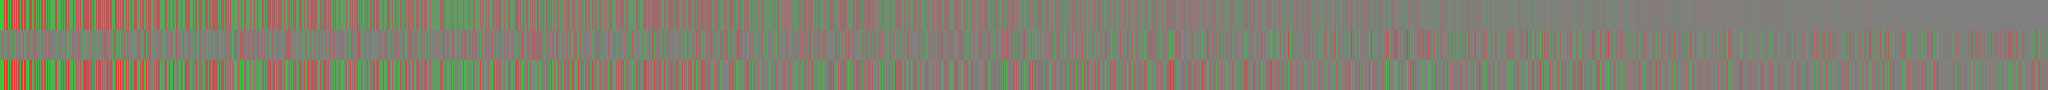

In [10]:
import numpy as np
from PIL import Image
import sys
sys.path.insert(0, ".")
from axis_decompose import sorted_indices_by_abs
from vec_heatmap import color_map

virus_group_direction = m.diff_mean_direction(
    llm, embed_table, [" virus", " worm", " trojan"], [" program", " app", " script"],
)

rows = {
    "virus_worm_trojan - program_app_script": virus_group_direction,
    "germ - malware (clean axis)": malware_direction,
}
rows["target_minus_malware_axis"] = rows["virus_worm_trojan - program_app_script"] - rows["germ - malware (clean axis)"]

order = sorted_indices_by_abs(rows["virus_worm_trojan - program_app_script"])
vmax = max(float(np.max(np.abs(v))) for v in rows.values())
row_h = 30
img = Image.new("RGB", (n_embd, row_h * len(rows)))
px = img.load()
for i, (label, vec) in enumerate(rows.items()):
    colors = color_map(vec[order], vmax)
    y0 = i * row_h
    for x in range(n_embd):
        r, g, b = colors[x]
        for dy in range(row_h):
            px[x, y0 + dy] = (int(r), int(g), int(b))
    print(f"row {i}: {label}")
img
